In [1]:
COLLECTION_NAME = "theory_synthesis"
PERSIST_DIRECTORY = "./vector_database"
embedding_model = "text-embedding-3-small"
PAPER_FOLDER = "./my_papers"

In [2]:
from modules.tools.retriever import PaperRetriever

retriever_tool = PaperRetriever(
    collection_name=COLLECTION_NAME,
    persist_directory=PERSIST_DIRECTORY,
    embedding_model=embedding_model
)

c:\Users\sahil\OneDrive\PhD\3. Empirical Study\Methodological Workflow\modules\tools\retriever.py:13: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  self._vectorstore = Chroma(


In [ ]:
#retriever_tool = retriever_tool.for_paper("2024 - 15.pdf", k = 10)

#docs = retriever_tool.invoke("What theory is used?")

### **1. Load YAML Prompts**

In [3]:
import yaml
from langchain_core.prompts import ChatPromptTemplate

def load_yaml_prompt(path: str):
    with open(path, "r") as f:
        config = yaml.safe_load(f)

    return ChatPromptTemplate.from_messages([
        ("system", config["instructions"]),
        ("human", "{input}")
    ],
    template_format="jinja2") # Escape curly braces in the prompt template

In [4]:
def load_vector_query(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    if "query" not in config:
        raise ValueError(f"'query' key not found in {path}")

    return {
        "query": config["query"],
        "k": config.get("k", 10),  # default fallback
        "name": config.get("name", None),
        "description": config.get("description", None)
    }

In [6]:
# testing
load_vector_query( "prompts/ds_gatekeeper/vector_query.yaml")


{'query': 'Extract sections that describe:\n- dataset description\n- data sources\n- modelling techniques\n- algorithms\n- machine learning\n- statistical modelling\n- NLP, clustering, deep learning\n- computational infrastructure',
 'k': 15,
 'name': 'ds_gatekeeper_vector_query',
 'description': 'Retrieve chunks related to modelling paradigms, dataset description, machine learning, statistical methods, and computational infrastructure.\n'}

### **2. Initialise LLM**

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",   # deterministic & cost-efficient
    temperature=0
)

### **3. Define LangGraph State**

In [6]:
from typing import TypedDict, List, Dict, Any

class GatekeeperState(TypedDict):
    paper_id: str
    raw_docs: List[Any]
    extracted_evidence: Dict
    classification_output: Dict
    audit_output: Dict

### **4. Node 1: Vector Retrieval**

In [7]:
def retrieve_chunks(state: GatekeeperState):
    retriever_tool = PaperRetriever(
        collection_name=COLLECTION_NAME,
        persist_directory=PERSIST_DIRECTORY,
        embedding_model=embedding_model
    ).for_paper(state["paper_id"], k=15)

    query = load_vector_query(
        "prompts/ds_gatekeeper/vector_search.yaml"
    )

    docs = retriever_tool.invoke(query["query"], k=query["k"])

    return {"raw_docs": docs}

### **5. Node 2: Gatekeeper Evidence Extractor**

In [8]:
def evidence_extractor(state: GatekeeperState):
    prompt = load_yaml_prompt(
        "prompts/ds_gatekeeper/retriever.yaml"
    )

    context_text = "\n\n".join(
        f"[Page {d.metadata.get('page_no')} | {d.metadata.get('section_heading')}]\n{d.page_content}"
        for d in state["raw_docs"]
    )

    response = llm.invoke(
        prompt.format_messages() + [
            ("user", context_text)
        ]
    )

    return {"extracted_evidence": response.content}

### **6. Node 3: Gatekeeper Classifier**

In [9]:
def classify_gatekeeper(state: GatekeeperState):
    prompt = load_yaml_prompt(
        "prompts/ds_gatekeeper/classifier.yaml"
    )

    response = llm.invoke(
        prompt.format_messages() + [
            ("user", state["extracted_evidence"])
        ]
    )

    return {"classification_output": response.content}

### **7. Node 4: Auditor**

In [10]:
def audit_gatekeeper(state: GatekeeperState):
    prompt = load_yaml_prompt(
        "prompts/ds_gatekeeper/auditor.yaml"
    )

    combined_input = f"""
    Classification Decision:
    {state['classification_output']}

    Evidence:
    {state['extracted_evidence']}
    """

    response = llm.invoke(
        prompt.format_messages() + [
            ("user", combined_input)
        ]
    )

    return {"audit_output": response.content}

## **8. Build LangGraph**

In [11]:
from langgraph.graph import StateGraph, END

builder = StateGraph(GatekeeperState)

builder.add_node("retrieve", retrieve_chunks)
builder.add_node("extract", evidence_extractor)
builder.add_node("classify", classify_gatekeeper)
builder.add_node("audit", audit_gatekeeper)

builder.set_entry_point("retrieve")

builder.add_edge("retrieve", "extract")
builder.add_edge("extract", "classify")
builder.add_edge("classify", "audit")
builder.add_edge("audit", END)

graph = builder.compile()

### **9. Run for one paper**

In [ ]:
result = graph.invoke({
    "paper_id": "2024 - 15.pdf"
})

print(result["audit_output"])

# **New Integrated Design**

In [6]:
import json

In [7]:
def load_yaml_prompt(path: str):
    with open(path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    return ChatPromptTemplate.from_messages(
        [
            ("system", config["instructions"]),
            ("human", "{{ input }}"),  # Jinja2 variable syntax
        ],
        template_format="jinja2",
    )

In [8]:
import json
import re

def parse_llm_json(text: str) -> dict:
    s = (text or "").strip()

    # remove markdown fences if present
    s = re.sub(r"^```(?:json)?\s*|\s*```$", "", s, flags=re.IGNORECASE | re.DOTALL).strip()

    # try direct parse
    try:
        return json.loads(s)
    except json.JSONDecodeError:
        pass

    # fix invalid single backslashes: \X -> \\X (only when not a valid JSON escape)
    s2 = re.sub(r'(?<!\\)\\(?!["\\/bfnrtu])', r'\\\\', s)

    try:
        return json.loads(s2)
    except json.JSONDecodeError as e:
        raise ValueError(f"LLM returned invalid JSON: {e}\nRaw:\n{s[:1200]}")

In [9]:
# Step 1: Update State Structure

from typing import TypedDict, Dict, Any, List

class DSRPState(TypedDict):
    paper_id: str
    gatekeeper: Dict[str, Any]
    dsrp_outputs: Dict[str, Any]



Important:

`state["dsrp_outputs"]["research_question"]` 

Each dimension writes into this dictionary.

In [10]:
# Step 2: Gatekeeper Node Wrapper

def gatekeeper_node(state: DSRPState):

    # 1️⃣ Load vector query
    vector_config = load_vector_query(
        "prompts/ds_gatekeeper/vector_query.yaml"
    )

    retriever_tool = PaperRetriever(
        collection_name=COLLECTION_NAME,
        persist_directory=PERSIST_DIRECTORY,
        embedding_model=embedding_model
    ).for_paper(
        state["paper_id"],
        k=vector_config["k"]
    )

    docs = retriever_tool.invoke(vector_config["query"])

    context_text = "\n\n".join(
        f"[Page {d.metadata.get('page_no')} | {d.metadata.get('section_heading')}]\n{d.page_content}"
        for d in docs
    )

    # 2️⃣ Evidence extraction
    retriever_prompt = load_yaml_prompt(
        "prompts/ds_gatekeeper/retriever.yaml"
    )

    evidence_response = llm.invoke(
        retriever_prompt.format_messages(input=context_text)
    )

    evidence_json = json.loads(evidence_response.content)

    # 3️⃣ Classification
    classifier_prompt = load_yaml_prompt(
        "prompts/ds_gatekeeper/classifier.yaml"
    )

    classification_response = llm.invoke(
        classifier_prompt.format_messages(
            input=json.dumps(evidence_json)
        )
    )

    classification_json = json.loads(classification_response.content)

    # 4️⃣ Audit
    auditor_prompt = load_yaml_prompt(
        "prompts/ds_gatekeeper/auditor.yaml"
    )

    audit_response = llm.invoke(
        auditor_prompt.format_messages(
            input=json.dumps(classification_json)
        )
    )

    audit_json = json.loads(audit_response.content)

    return {
        "gatekeeper": audit_json
    }

In [12]:
# Test Gatekeeper Node
test_state = DSRPState(
    paper_id="2024 - 15.pdf",
    gatekeeper={},
    dsrp_outputs={}
)
gatekeeper_result = gatekeeper_node(test_state)
print(gatekeeper_result)

{'gatekeeper': {'final_classification': 'Include', 'confidence': 0.9, 'validated_reasoning': 'The paper utilizes a deep learning model (ChatGPT) for sentiment analysis, which is a clear application of the machine learning/algorithmic modelling paradigm [1]. Additionally, it employs Latent Dirichlet Allocation (LDA) for topic extraction, further supporting its classification as data science-oriented research [2]. The integration of these advanced techniques indicates a strong focus on algorithmic modelling and data analysis, aligning with the criteria for inclusion in data science research.', 'validated_bibliography': [{'id': 1, 'page': 4, 'section': '1. Introduction', 'direct_quote': 'Initially, it uses a deep learning model, predominantly ChatGPT, to conduct sentiment analysis and identify sentiment polarities within online reviews.'}, {'id': 2, 'page': 4, 'section': '1. Introduction', 'direct_quote': 'Subsequently, the Latent Dirichlet Allocation (LDA) serves as a pivotal mechanism f

In [41]:
gatekeeper_result["gatekeeper"]["final_classification"]


'Include'

In [17]:
# Step 3: Conditional Routing After Gatekeeper

from langgraph.graph import END

def route_after_gatekeeper(state: DSRPState):
    if state["gatekeeper"]["final_classification"] == "Exclude":
        return END
    return "research_question"

In [18]:
# Step 4: Generic DSRP Dimension Executor

def run_dsrp_dimension(state: DSRPState, dimension_name: str):

    # Load vector query
    vector_config = load_vector_query(
        f"prompts/dsrp/{dimension_name}/vector_query.yaml"
    )

    retriever_tool = PaperRetriever(
        collection_name=COLLECTION_NAME,
        persist_directory=PERSIST_DIRECTORY,
        embedding_model=embedding_model
    ).for_paper(
        state["paper_id"],
        k=vector_config["k"]
    )

    docs = retriever_tool.invoke(vector_config["query"])

    # Format context
    context_text = "\n\n".join(
        f"[Page {d.metadata.get('page_no')} | {d.metadata.get('section_heading')}]\n{d.page_content}"
        for d in docs
    )

    # Evidence extraction
    retriever_prompt = load_yaml_prompt(
        f"prompts/dsrp/{dimension_name}/retriever.yaml"
    )

    evidence_response = llm.invoke(
        retriever_prompt.format_messages(input=context_text)
    )

    evidence_json = parse_llm_json(evidence_response.content)

    # Classification
    classifier_prompt = load_yaml_prompt(
        f"prompts/dsrp/{dimension_name}/classifier.yaml"
    )

    classification_response = llm.invoke(
        classifier_prompt.format_messages(
            input=json.dumps(evidence_json)
        )
    )

    classification_json = parse_llm_json(classification_response.content)

    # Audit
    auditor_prompt = load_yaml_prompt(
        f"prompts/dsrp/{dimension_name}/auditor.yaml"
    )

    audit_response = llm.invoke(
        auditor_prompt.format_messages(
            input=json.dumps(classification_json)
        )
    )

    audit_json = parse_llm_json(audit_response.content)

    # Store result
    state["dsrp_outputs"][dimension_name] = audit_json

    return {"dsrp_outputs": state["dsrp_outputs"]}

In [34]:
# Test DSRP Dimension Executor
test_dsrp_state = DSRPState(
    paper_id="2024 - 15.pdf",
    gatekeeper={
        "final_classification": "Include"
    },
    dsrp_outputs={}
)
result = run_dsrp_dimension(test_dsrp_state, "data_preprocessing")
print(result["dsrp_outputs"]["data_preprocessing"])

{'validated_data_cleaning': {'status': 'Transparently Described', 'evidence_ids': [1]}, 'validated_data_reduction': {'status': 'Not Reported', 'evidence_ids': []}, 'validated_data_transformation': {'status': 'Mentioned', 'evidence_ids': [1]}, 'confidence': 0.9, 'validated_reasoning': 'Data cleaning is transparently described with specific actions taken (removal of redundant spaces, punctuation, and characters, and text normalization). Data transformation is mentioned but lacks detailed explanation. Data reduction is not reported.', 'validated_bibliography': [{'id': 1, 'page': '6', 'section': '3.2 Sentiment analysis', 'direct_quote': 'During the preprocessing stage, redundant spaces, punctuation and characters are removed, and the text is converted to lowercase. In addition, word tokenization and normalization are performed.'}, {'id': 2, 'page': '5', 'section': '3.1 Data collection and preprocessing', 'direct_quote': 'The initial phase involved the collection of data pertaining to the F

In [ ]:
# Render Result in HTML (for Jupyter)
from IPython.display import display, HTML
def render_json_as_html(json_data: dict):
    html_content = f"<pre>{json.dumps(json_data, indent=2)}</pre>"
    display(HTML(html_content))

render_json_as_html(result["dsrp_outputs"]["data_preprocessing"])

In [19]:
# Step 5: Define Nodes

# research_question
def research_question_node(state: DSRPState):
    return run_dsrp_dimension(state, "research_question")

# data_understanding
def data_understanding_node(state: DSRPState):
    return run_dsrp_dimension(state, "data_understanding")

# data_preprocessing
def data_preprocessing_node(state: DSRPState):
    return run_dsrp_dimension(state, "data_preprocessing")

In [20]:
# modelling 

def modelling_node(state: DSRPState):

    base_path = "prompts/dsrp/modelling"

    foundational_path = f"{base_path}/foundational"
    specialised_path = f"{base_path}/specialised"

    # =====================================================
    # 1️⃣ FOUNDATIONAL VECTOR RETRIEVAL
    # =====================================================

    vector_config = load_vector_query(
        f"{foundational_path}/vector_query.yaml"
    )

    retriever_tool = PaperRetriever(
        collection_name=COLLECTION_NAME,
        persist_directory=PERSIST_DIRECTORY,
        embedding_model=embedding_model
    ).for_paper(
        state["paper_id"],
        k=vector_config["k"]
    )

    docs = retriever_tool.invoke(vector_config["query"])

    context_text = "\n\n".join(
        f"[Page {d.metadata.get('page_no')} | {d.metadata.get('section_heading')}]\n{d.page_content}"
        for d in docs
    )

    # =====================================================
    # 2️⃣ FOUNDATIONAL EVIDENCE EXTRACTION
    # =====================================================

    retriever_prompt = load_yaml_prompt(
        f"{foundational_path}/retriever.yaml"
    )

    evidence_response = llm.invoke(
        retriever_prompt.format_messages(input=context_text)
    )

    evidence_json = parse_llm_json(evidence_response.content)

    # Filter evidence based on "method_used" flag

    evidence_json["modelling_evidence"] = [
        e for e in evidence_json["modelling_evidence"]
        if e.get("method_used", True)
    ]

    # =====================================================
    # 3️⃣ FOUNDATIONAL CLASSIFICATION
    # =====================================================

    foundational_prompt = load_yaml_prompt(
        f"{foundational_path}/foundational_classifier.yaml"
    )

    foundational_response = llm.invoke(
        foundational_prompt.format_messages(
            input=json.dumps(evidence_json)
        )
    )

    foundational_json = parse_llm_json(foundational_response.content)

    # =====================================================
    # 4️⃣ ML LEARNING CLASSIFICATION
    # =====================================================

    ml_json = {}

    if foundational_json.get("foundational_paradigm") in [
        "Machine Learning",
        "Hybrid / Integrated"
    ]:

        ml_prompt = load_yaml_prompt(
            f"{foundational_path}/ml_learning_classifier.yaml"
        )

        ml_response = llm.invoke(
            ml_prompt.format_messages(
                input=json.dumps(evidence_json)
            )
        )

        ml_json = parse_llm_json(ml_response.content)

    # =====================================================
    # 5️⃣ FOUNDATIONAL AUDIT
    # =====================================================

    foundational_audit_prompt = load_yaml_prompt(
        f"{foundational_path}/auditor.yaml"
    )

    foundational_audit_response = llm.invoke(
        foundational_audit_prompt.format_messages(
            input=json.dumps({
                "foundational": foundational_json,
                "ml_details": ml_json,
                "evidence": evidence_json
            })
        )
    )

    foundational_audit_json = parse_llm_json(
        foundational_audit_response.content
    )

    # =====================================================
    # 6️⃣ SPECIALISED VECTOR RETRIEVAL
    # =====================================================

    vector_config = load_vector_query(
        f"{specialised_path}/vector_query.yaml"
    )

    retriever_tool = PaperRetriever(
        collection_name=COLLECTION_NAME,
        persist_directory=PERSIST_DIRECTORY,
        embedding_model=embedding_model
    ).for_paper(
        state["paper_id"],
        k=vector_config["k"]
    )

    docs = retriever_tool.invoke(vector_config["query"])

    specialised_context = "\n\n".join(
        f"[Page {d.metadata.get('page_no')} | {d.metadata.get('section_heading')}]\n{d.page_content}"
        for d in docs
    )

    # =====================================================
    # 7️⃣ SPECIALISED EVIDENCE EXTRACTION
    # =====================================================

    retriever_prompt = load_yaml_prompt(
        f"{specialised_path}/retriever.yaml"
    )

    specialised_evidence_response = llm.invoke(
        retriever_prompt.format_messages(
            input=specialised_context
        )
    )

    specialised_evidence_json = parse_llm_json(
        specialised_evidence_response.content
    )

    # Filter evidence based on "method_used" flag
    specialised_evidence_json["modelling_evidence"] = [
        e for e in specialised_evidence_json["modelling_evidence"]
        if e.get("method_used", True)
    ]

    # =====================================================
    # 8️⃣ SPECIALISED CLASSIFICATION
    # =====================================================

    specialised_prompt = load_yaml_prompt(
        f"{specialised_path}/specialised_classifier.yaml"
    )

    specialised_response = llm.invoke(
        specialised_prompt.format_messages(
            input=json.dumps(specialised_evidence_json)
        )
    )

    specialised_json = parse_llm_json(
        specialised_response.content
    )

    # =====================================================
    # 9️⃣ SUB-SPECIALISED CLASSIFICATION
    # =====================================================

    sub_json = {}

    if specialised_json.get("specialised_paradigms"):

        sub_prompt = load_yaml_prompt(
            f"{specialised_path}/sub_specialised_classifier.yaml"
        )

        sub_response = llm.invoke(
            sub_prompt.format_messages(
                input=json.dumps({
                    "evidence": specialised_evidence_json,
                    "specialised": specialised_json
                })
            )
        )

        sub_json = parse_llm_json(sub_response.content)

    # =====================================================
    # 🔟 SPECIALISED AUDIT
    # =====================================================

    specialised_audit_prompt = load_yaml_prompt(
        f"{specialised_path}/auditor.yaml"
    )

    specialised_audit_response = llm.invoke(
        specialised_audit_prompt.format_messages(
            input=json.dumps({
                "specialised": specialised_json,
                "sub_paradigms": sub_json,
                "evidence": specialised_evidence_json
            })
        )
    )

    specialised_audit_json = parse_llm_json(
        specialised_audit_response.content
    )

    # =====================================================
    # 1️⃣1️⃣ GLOBAL MODELLING AUDIT
    # =====================================================

    global_audit_prompt = load_yaml_prompt(
        f"{base_path}/auditor.yaml"
    )

    audit_response = llm.invoke(
        global_audit_prompt.format_messages(
            input=json.dumps({
                "foundational": foundational_audit_json,
                "specialised": specialised_audit_json
            })
        )
    )

    audit_json = parse_llm_json(audit_response.content)

    # =====================================================
    # 1️⃣2️⃣ STORE FINAL OUTPUT
    # =====================================================

    state["dsrp_outputs"]["modelling"] = audit_json

    return {"dsrp_outputs": state["dsrp_outputs"]}

In [51]:
# Test Research Question Node
test_state = DSRPState(
    paper_id="2024 - 15.pdf",
    gatekeeper={},
    dsrp_outputs={}
)
result = modelling_node(test_state)
print(result)

{'dsrp_outputs': {'modelling': {'foundational_paradigm': 'Hybrid / Integrated', 'ml_learning_type': 'Supervised Learning', 'ml_problem_type': 'classification', 'specialised_paradigms': ['Natural Language Processing'], 'tsa_model_type': '', 'nlp_task': 'sentiment_analysis', 'nlp_method_type': 'ml_based', 'spatial_method_type': '', 'network_method_type': '', 'emerging_modality': '', 'confidence': 1.0, 'validated_reasoning': 'The foundational paradigm is correctly classified as hybrid since both statistical and ML approaches are used. The ML learning type is consistent with the reported algorithms, and the problem type aligns logically with the learning type. The deep learning flag is accurate as ChatGPT is a neural architecture. The study employs methods such as sentiment analysis using ChatGPT and topic extraction using Latent Dirichlet Allocation (LDA), both of which are indicative of Natural Language Processing. These methods are explicitly applied in the study as evidenced by the pro

### Evaluation Nodes

**Metric Based Evaluation**

In [21]:
#foundational metrics node
def evaluation_metrics_foundational_node(state: DSRPState):

    base_path = "prompts/dsrp/evaluation/metrics/foundational"

    # =====================================================
    # 1️⃣ VECTOR RETRIEVAL
    # =====================================================

    vector_config = load_vector_query(
        f"{base_path}/vector_query.yaml"
    )

    retriever_tool = PaperRetriever(
        collection_name=COLLECTION_NAME,
        persist_directory=PERSIST_DIRECTORY,
        embedding_model=embedding_model
    ).for_paper(
        state["paper_id"],
        k=vector_config["k"]
    )

    docs = retriever_tool.invoke(vector_config["query"])

    context_text = "\n\n".join(
        f"[Page {d.metadata.get('page_no')} | {d.metadata.get('section_heading')}]\n{d.page_content}"
        for d in docs
    )

    # =====================================================
    # 2️⃣ EVIDENCE EXTRACTION
    # =====================================================

    retriever_prompt = load_yaml_prompt(
        f"{base_path}/retriever.yaml"
    )

    evidence_response = llm.invoke(
        retriever_prompt.format_messages(input=context_text)
    )

    evidence_json = parse_llm_json(evidence_response.content)

    # =====================================================
    # 3️⃣ LOAD MODELLING OUTPUT (CRITICAL CONTEXT)
    # =====================================================

    modelling_output = state["dsrp_outputs"].get("modelling", {})

    foundational_paradigm = modelling_output.get("foundational_paradigm")

    ml_learning_type = modelling_output.get("ml_learning_type")

    # =====================================================
    # 4️⃣ METRICS CLASSIFICATION
    # =====================================================

    classifier_prompt = load_yaml_prompt(
        f"{base_path}/classifier.yaml"
    )

    classifier_input = {
        "modelling_context": {
            "foundational_paradigm": foundational_paradigm,
            "ml_learning_type": ml_learning_type
        },
        "evidence": evidence_json
    }

    classification_response = llm.invoke(
        classifier_prompt.format_messages(
            input=json.dumps(classifier_input)
        )
    )

    classification_json = parse_llm_json(
        classification_response.content
    )

    # =====================================================
    # 5️⃣ AUDIT VALIDATION
    # =====================================================

    auditor_prompt = load_yaml_prompt(
        f"{base_path}/auditor.yaml"
    )

    audit_input = {
        "modelling_context": {
            "foundational_paradigm": foundational_paradigm,
            "ml_learning_type": ml_learning_type
        },
        "classification": classification_json
    }

    audit_response = llm.invoke(
        auditor_prompt.format_messages(
            input=json.dumps(audit_input)
        )
    )

    audit_json = parse_llm_json(audit_response.content)

    # =====================================================
    # 6️⃣ STORE RESULT
    # =====================================================

    state["dsrp_outputs"]["evaluation_metrics_foundational"] = audit_json

    return {"dsrp_outputs": state["dsrp_outputs"]}

In [22]:
# Evaluation metrics for specialised paradigms node

def evaluation_metrics_specialised_node(state: DSRPState):

    base_path = "prompts/dsrp/evaluation/metrics/specialised"

    # =====================================================
    # 1️⃣ LOAD MODELLING OUTPUT
    # =====================================================

    modelling_output = state["dsrp_outputs"].get("modelling", {})

    specialised_paradigms = modelling_output.get("specialised_paradigms", [])

    # If no specialised paradigms exist, skip evaluation
    if not specialised_paradigms:
        state["dsrp_outputs"]["evaluation_metrics_specialised"] = {
            "specialised_metrics_reported": [],
            "evaluation_quality": "Not applicable",
            "confidence": 1.0,
            "validated_reasoning": "No specialised analytical paradigms were detected in the modelling stage.",
            "validated_bibliography": [],
            "audit_commentary": ""
        }

        return {"dsrp_outputs": state["dsrp_outputs"]}

    # =====================================================
    # 2️⃣ VECTOR RETRIEVAL
    # =====================================================

    vector_config = load_vector_query(
        f"{base_path}/vector_query.yaml"
    )

    retriever_tool = PaperRetriever(
        collection_name=COLLECTION_NAME,
        persist_directory=PERSIST_DIRECTORY,
        embedding_model=embedding_model
    ).for_paper(
        state["paper_id"],
        k=vector_config["k"]
    )

    docs = retriever_tool.invoke(vector_config["query"])

    context_text = "\n\n".join(
        f"[Page {d.metadata.get('page_no')} | {d.metadata.get('section_heading')}]\n{d.page_content}"
        for d in docs
    )

    # =====================================================
    # 3️⃣ EVIDENCE EXTRACTION
    # =====================================================

    retriever_prompt = load_yaml_prompt(
        f"{base_path}/retriever.yaml"
    )

    evidence_response = llm.invoke(
        retriever_prompt.format_messages(input=context_text)
    )

    evidence_json = parse_llm_json(evidence_response.content)

    # =====================================================
    # 4️⃣ SPECIALISED METRICS CLASSIFICATION
    # =====================================================

    classifier_prompt = load_yaml_prompt(
        f"{base_path}/classifier.yaml"
    )

    classifier_input = {
        "specialised_paradigms": specialised_paradigms,
        "evidence": evidence_json
    }

    classification_response = llm.invoke(
        classifier_prompt.format_messages(
            input=json.dumps(classifier_input)
        )
    )

    classification_json = parse_llm_json(
        classification_response.content
    )

    # =====================================================
    # 5️⃣ AUDIT VALIDATION
    # =====================================================

    auditor_prompt = load_yaml_prompt(
        f"{base_path}/auditor.yaml"
    )

    audit_input = {
        "specialised_paradigms": specialised_paradigms,
        "classification": classification_json
    }

    audit_response = llm.invoke(
        auditor_prompt.format_messages(
            input=json.dumps(audit_input)
        )
    )

    audit_json = parse_llm_json(audit_response.content)

    # =====================================================
    # 6️⃣ STORE OUTPUT
    # =====================================================

    state["dsrp_outputs"]["evaluation_metrics_specialised"] = audit_json

    return {"dsrp_outputs": state["dsrp_outputs"]}

**Epistemological Evaluation**

*Theoretical Orientation*

In [23]:
def evaluation_theoretical_orientation_node(state: DSRPState):

    base_path = "prompts/dsrp/evaluation/epistemological/theoretical_orientation"

    # =====================================================
    # 1️⃣ VECTOR RETRIEVAL
    # =====================================================

    vector_config = load_vector_query(
        f"{base_path}/vector_query.yaml"
    )

    retriever_tool = PaperRetriever(
        collection_name=COLLECTION_NAME,
        persist_directory=PERSIST_DIRECTORY,
        embedding_model=embedding_model
    ).for_paper(
        state["paper_id"],
        k=vector_config["k"]
    )

    docs = retriever_tool.invoke(vector_config["query"])

    context_text = "\n\n".join(
        f"[Page {d.metadata.get('page_no')} | {d.metadata.get('section_heading')}]\n{d.page_content}"
        for d in docs
    )

    # =====================================================
    # 2️⃣ EVIDENCE EXTRACTION
    # =====================================================

    retriever_prompt = load_yaml_prompt(
        f"{base_path}/retriever.yaml"
    )

    evidence_response = llm.invoke(
        retriever_prompt.format_messages(input=context_text)
    )

    evidence_json = parse_llm_json(evidence_response.content)

    # =====================================================
    # 3️⃣ THEORY CLASSIFICATION
    # =====================================================

    classifier_prompt = load_yaml_prompt(
        f"{base_path}/classifier.yaml"
    )

    classification_response = llm.invoke(
        classifier_prompt.format_messages(
            input=json.dumps(evidence_json)
        )
    )

    classification_json = parse_llm_json(
        classification_response.content
    )

    # =====================================================
    # 4️⃣ AUDIT VALIDATION
    # =====================================================

    auditor_prompt = load_yaml_prompt(
        f"{base_path}/auditor.yaml"
    )

    audit_response = llm.invoke(
        auditor_prompt.format_messages(
            input=json.dumps(classification_json)
        )
    )

    audit_json = parse_llm_json(audit_response.content)

    # =====================================================
    # 5️⃣ STORE OUTPUT
    # =====================================================

    state["dsrp_outputs"]["evaluation_theoretical_orientation"] = audit_json

    return {"dsrp_outputs": state["dsrp_outputs"]}

*Interpretability*

In [37]:
def evaluation_interpretability_node(state: DSRPState):

    base_path = "prompts/dsrp/evaluation/epistemological/interpretability"

    # =====================================================
    # 1️⃣ VECTOR RETRIEVAL
    # =====================================================

    vector_config = load_vector_query(
        f"{base_path}/vector_query.yaml"
    )

    retriever_tool = PaperRetriever(
        collection_name=COLLECTION_NAME,
        persist_directory=PERSIST_DIRECTORY,
        embedding_model=embedding_model
    ).for_paper(
        state["paper_id"],
        k=vector_config["k"]
    )

    docs = retriever_tool.invoke(vector_config["query"])

    context_text = "\n\n".join(
        f"[Page {d.metadata.get('page_no')} | {d.metadata.get('section_heading')}]\n{d.page_content}"
        for d in docs
    )

    # =====================================================
    # 2️⃣ EVIDENCE EXTRACTION
    # =====================================================

    retriever_prompt = load_yaml_prompt(
        f"{base_path}/retriever.yaml"
    )

    evidence_response = llm.invoke(
        retriever_prompt.format_messages(input=context_text)
    )

    evidence_json = parse_llm_json(evidence_response.content)

    # =====================================================
    # 3️⃣ INTERPRETABILITY CLASSIFICATION
    # =====================================================

    classifier_prompt = load_yaml_prompt(
        f"{base_path}/classifier.yaml"
    )

    classification_response = llm.invoke(
        classifier_prompt.format_messages(
            input=json.dumps(evidence_json)
        )
    )

    classification_json = parse_llm_json(
        classification_response.content
    )

    # =====================================================
    # 4️⃣ AUDIT VALIDATION
    # =====================================================

    auditor_prompt = load_yaml_prompt(
        f"{base_path}/auditor.yaml"
    )

    audit_response = llm.invoke(
        auditor_prompt.format_messages(
            input=json.dumps(classification_json)
        )
    )

    audit_json = parse_llm_json(audit_response.content)

    # =====================================================
    # 5️⃣ STORE OUTPUT
    # =====================================================

    state["dsrp_outputs"]["evaluation_interpretability"] = audit_json

    return {"dsrp_outputs": state["dsrp_outputs"]}

*Ethical Social Evaluation*

In [45]:
def evaluation_ethical_social_node(state: DSRPState):

    base_path = "prompts/dsrp/evaluation/ethical_social"

    # VECTOR RETRIEVAL
    vector_config = load_vector_query(
        f"{base_path}/vector_query.yaml"
    )

    retriever_tool = PaperRetriever(
        collection_name=COLLECTION_NAME,
        persist_directory=PERSIST_DIRECTORY,
        embedding_model=embedding_model
    ).for_paper(
        state["paper_id"],
        k=vector_config["k"]
    )

    docs = retriever_tool.invoke(vector_config["query"])

    context_text = "\n\n".join(
        f"[Page {d.metadata.get('page_no')} | {d.metadata.get('section_heading')}]\n{d.page_content}"
        for d in docs
    )

    # EVIDENCE EXTRACTION
    retriever_prompt = load_yaml_prompt(
        f"{base_path}/retriever.yaml"
    )

    evidence_response = llm.invoke(
        retriever_prompt.format_messages(input=context_text)
    )

    evidence_json = parse_llm_json(evidence_response.content)

    # CLASSIFICATION
    classifier_prompt = load_yaml_prompt(
        f"{base_path}/classifier.yaml"
    )

    classification_response = llm.invoke(
        classifier_prompt.format_messages(
            input=json.dumps(evidence_json)
        )
    )

    classification_json = parse_llm_json(
        classification_response.content
    )

    # AUDIT
    auditor_prompt = load_yaml_prompt(
        f"{base_path}/auditor.yaml"
    )

    audit_response = llm.invoke(
        auditor_prompt.format_messages(
            input=json.dumps(classification_json)
        )
    )

    audit_json = parse_llm_json(audit_response.content)

    # STORE OUTPUT
    state["dsrp_outputs"]["evaluation_ethical_social"] = audit_json

    return {"dsrp_outputs": state["dsrp_outputs"]}

In [53]:
# =====================================================
# Test Evaluation Metrics Node
# =====================================================

test_state = DSRPState(
    paper_id="2024 - 15.pdf",
    gatekeeper={},

    dsrp_outputs={
        "modelling": {
            "foundational_paradigm": "Hybrid / Integrated",
            "ml_learning_type": "Supervised Learning",
            "ml_problem_type": "classification",
            "specialised_paradigms": ["Natural Language Processing"],
            "tsa_model_type": "",
            "nlp_task": "sentiment_analysis",
            "nlp_method_type": "ml_based",
            "spatial_method_type": "",
            "network_method_type": "",
            "emerging_modality": "",
            "confidence": 1.0
        }
    }
)

result = evaluation_ethical_social_node(test_state)

print(result)

{'dsrp_outputs': {'modelling': {'foundational_paradigm': 'Hybrid / Integrated', 'ml_learning_type': 'Supervised Learning', 'ml_problem_type': 'classification', 'specialised_paradigms': ['Natural Language Processing'], 'tsa_model_type': '', 'nlp_task': 'sentiment_analysis', 'nlp_method_type': 'ml_based', 'spatial_method_type': '', 'network_method_type': '', 'emerging_modality': '', 'confidence': 1.0}, 'evaluation_ethical_social': {'privacy_protection_reported': 'No', 'bias_fairness_considered': 'No', 'societal_impact_discussed': 'No', 'ethical_reflection_level': 'Low', 'confidence': 1.0, 'validated_reasoning': 'The study does not report any safeguards for privacy or data protection, does not discuss any issues related to bias or fairness, and does not address potential societal impacts. Therefore, it reflects a low level of ethical reflection.', 'validated_bibliography': [], 'audit_commentary': 'All classifications are supported by the evidence from the study.'}}}


In [54]:
# Render Result in HTML (for Jupyter)
from IPython.display import display, HTML
def render_json_as_html(json_data: dict):
    html_content = f"<pre>{json.dumps(json_data, indent=2)}</pre>"
    display(HTML(html_content))

render_json_as_html(result["dsrp_outputs"]["evaluation_ethical_social"])

In [55]:
# Step 6: Build Master Graph

from langgraph.graph import StateGraph, END

builder = StateGraph(DSRPState)

builder.add_node("gatekeeper", gatekeeper_node)
builder.add_node("research_question", research_question_node)
builder.add_node("data_understanding", data_understanding_node)
builder.add_node("data_preprocessing", data_preprocessing_node)
builder.add_node("modelling", modelling_node)
builder.add_node("evaluation_metrics_foundational_node", evaluation_metrics_foundational_node)
builder.add_node("evaluation_metrics_specialised_node", evaluation_metrics_specialised_node)
builder.add_node("evaluation_theoretical_orientation_node", evaluation_theoretical_orientation_node)
builder.add_node("evaluation_interpretability_node", evaluation_interpretability_node)
builder.add_node("evaluation_ethical_social_node", evaluation_ethical_social_node)


builder.set_entry_point("gatekeeper")

# Conditional routing after gatekeeper
builder.add_conditional_edges(
    "gatekeeper",
    route_after_gatekeeper
)

# Sequential edges
builder.add_edge("research_question", "data_understanding")
builder.add_edge("data_understanding", "data_preprocessing")
builder.add_edge("data_preprocessing", "modelling")
builder.add_edge("modelling", "evaluation_metrics_foundational_node")
builder.add_edge("evaluation_metrics_foundational_node", "evaluation_metrics_specialised_node")
builder.add_edge("evaluation_metrics_specialised_node", "evaluation_theoretical_orientation_node")
builder.add_edge("evaluation_theoretical_orientation_node", "evaluation_interpretability_node")
builder.add_edge("evaluation_interpretability_node", "evaluation_ethical_social_node")
builder.add_edge("evaluation_ethical_social_node", END)



graph = builder.compile()

In [59]:
# Step 6.A: Build Master Graph (Parallel DSRP Nodes)

from langgraph.graph import StateGraph, END

builder = StateGraph(DSRPState)

builder.add_node("gatekeeper", gatekeeper_node)
builder.add_node("research_question", research_question_node)
builder.add_node("data_understanding", data_understanding_node)
builder.add_node("data_preprocessing", data_preprocessing_node)
builder.add_node("modelling", modelling_node)
builder.add_node("evaluation_metrics_foundational_node", evaluation_metrics_foundational_node)
builder.add_node("evaluation_metrics_specialised_node", evaluation_metrics_specialised_node)
builder.add_node("evaluation_theoretical_orientation_node", evaluation_theoretical_orientation_node)
builder.add_node("evaluation_interpretability_node", evaluation_interpretability_node)
builder.add_node("evaluation_ethical_social_node", evaluation_ethical_social_node)



builder.set_entry_point("gatekeeper")

# Conditional routing after gatekeeper
builder.add_conditional_edges(
    "gatekeeper",
    route_after_gatekeeper
)

# Parallel edges from gatekeeper to all DSRP nodes
builder.add_edge("gatekeeper", "research_question")
builder.add_edge("gatekeeper", "data_understanding")
builder.add_edge("gatekeeper", "data_preprocessing")
builder.add_edge("gatekeeper", "modelling")
builder.add_edge("gatekeeper", "evaluation_metrics_foundational_node")
builder.add_edge("evaluation_metrics_foundational_node", "evaluation_metrics_specialised_node")
builder.add_edge("gatekeeper", "evaluation_theoretical_orientation_node")
builder.add_edge("gatekeeper", "evaluation_interpretability_node")
builder.add_edge("gatekeeper", "evaluation_ethical_social_node")

# End edges from each DSRP node to END
builder.add_edge("research_question", END)
builder.add_edge("data_understanding", END)
builder.add_edge("data_preprocessing", END)
builder.add_edge("modelling", END) 
builder.add_edge("evaluation_metrics_foundational_node", "evaluation_metrics_specialised_node")
builder.add_edge("evaluation_metrics_specialised_node", END) 
builder.add_edge("evaluation_theoretical_orientation_node", END)
builder.add_edge("evaluation_interpretability_node", END)
builder.add_edge("evaluation_ethical_social_node", END)


graph = builder.compile()

See as a Image


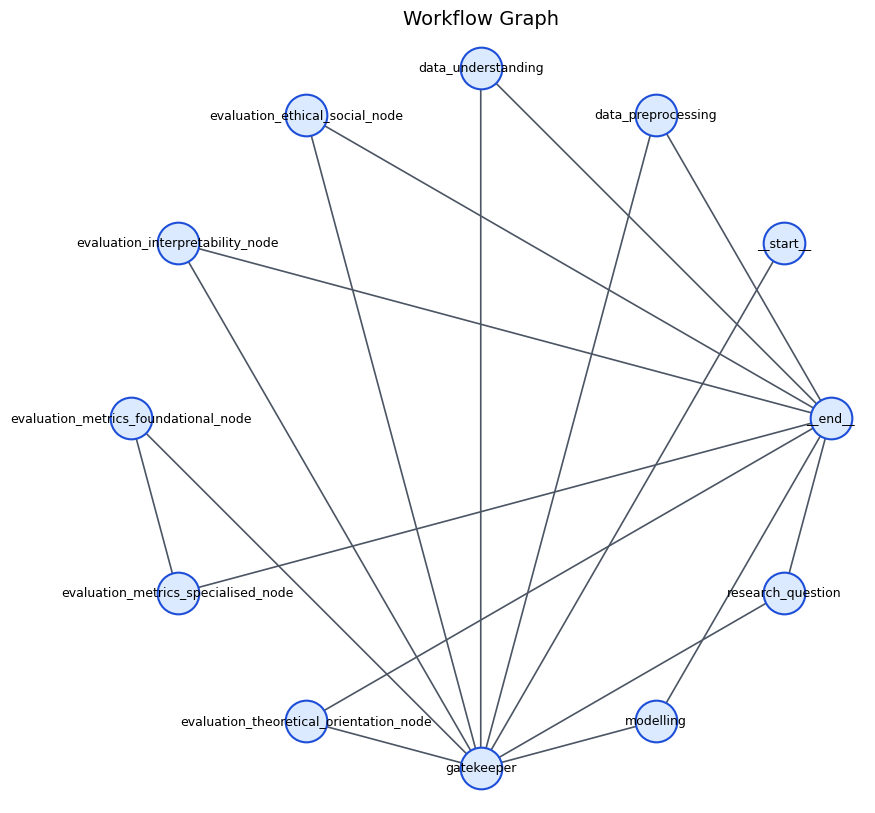

In [73]:
from IPython.display import Image, Markdown, display

compiled_graph = builder.compile().get_graph()

try:
    # Preferred: local PNG rendering as an actual image plot
    png_bytes = compiled_graph.draw_png()
    display(Image(png_bytes))
except Exception as e:
    # Fallback: render a basic directed graph plot with matplotlib.
    try:
        import re
        import math
        import matplotlib.pyplot as plt

        mermaid_text = compiled_graph.draw_mermaid()
        edges = re.findall(r"^\s*([A-Za-z0-9_]+)\s*-->\s*([A-Za-z0-9_]+);", mermaid_text, flags=re.MULTILINE)

        nodes = sorted(set([n for edge in edges for n in edge]))
        if not nodes:
            raise ValueError("No nodes parsed from Mermaid output")

        # Circular layout
        n = len(nodes)
        radius = 4.0
        pos = {}
        for i, node in enumerate(nodes):
            angle = 2 * math.pi * i / n
            pos[node] = (radius * math.cos(angle), radius * math.sin(angle))

        fig, ax = plt.subplots(figsize=(10, 10))

        # Draw edges with arrows
        for src, dst in edges:
            x1, y1 = pos[src]
            x2, y2 = pos[dst]
            ax.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops={"arrowstyle": "->", "lw": 1.2, "color": "#4b5563"},
            )

        # Draw nodes and labels
        for node, (x, y) in pos.items():
            ax.scatter(x, y, s=900, color="#dbeafe", edgecolors="#1d4ed8", linewidths=1.5, zorder=3)
            ax.text(x, y, node, ha="center", va="center", fontsize=9, zorder=4)

        ax.set_title("Workflow Graph", fontsize=14)
        ax.set_aspect("equal")
        ax.axis("off")
        plt.show()

    except Exception as fallback_error:
        mermaid_text = compiled_graph.draw_mermaid()
        display(Markdown("**Could not render image plot. Showing Mermaid text instead.**"))
        display(Markdown("```mermaid\n" + mermaid_text + "\n```"))
        print(f"draw_png error: {type(e).__name__}: {e}")
        print(f"plot fallback error: {type(fallback_error).__name__}: {fallback_error}")

In [29]:
# Step 7: Run Workflow
result = graph.invoke({
    "paper_id": "2024 - 15.pdf",
    "dsrp_outputs": {}
})

print(result)

InvalidUpdateError: At key 'dsrp_outputs': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

In [50]:
def render_result_html(result: dict):
    """
    Renders the DSRP workflow result in clean HTML format using IPython display.
    Supports generic and dimension-specific audited output structures.
    """
    from IPython.display import display, Markdown

    def as_dict(value):
        return value if isinstance(value, dict) else {}

    def as_list(value):
        return value if isinstance(value, list) else []

    def render_simple_list(title: str, values):
        values = as_list(values)
        display(Markdown(f"#### {title}"))
        if values:
            for item in values:
                display(Markdown(f"- {item}"))
        else:
            display(Markdown("- *Not available*"))

    def render_bibliography(bibliography):
        bibliography = as_list(bibliography)
        if not bibliography:
            display(Markdown("- *No bibliography provided*"))
            return

        for bib in bibliography:
            if isinstance(bib, dict):
                display(Markdown(
                    f"**[{bib.get('id', 'N/A')}]** Page {bib.get('page', 'N/A')} | {bib.get('section', 'N/A')}\n"
                    f"> {bib.get('direct_quote', 'N/A')}"
                ))
            else:
                display(Markdown(f"- {bib}"))

    def render_data_understanding(data: dict):
        render_simple_list(
            "Data Category",
            data.get("validated_data_category", data.get("data_category", []))
        )
        render_simple_list(
            "Data Format",
            data.get("validated_data_format", data.get("data_format", []))
        )
        render_simple_list(
            "Data Characteristics",
            data.get("validated_data_characteristics", data.get("data_characteristics", []))
        )

    def render_data_preprocessing(data: dict):
        component_map = [
            ("Data Cleaning", "validated_data_cleaning", "data_cleaning"),
            ("Data Reduction", "validated_data_reduction", "data_reduction"),
            ("Data Transformation", "validated_data_transformation", "data_transformation"),
        ]

        for label, validated_key, fallback_key in component_map:
            component = as_dict(data.get(validated_key, data.get(fallback_key, {})))
            status = component.get("status", "Not available")
            evidence_ids = as_list(component.get("evidence_ids", []))

            display(Markdown(f"#### {label}"))
            display(Markdown(f"- **Status:** `{status}`"))
            if evidence_ids:
                display(Markdown(f"- **Evidence IDs:** {', '.join(map(str, evidence_ids))}"))
            else:
                display(Markdown("- **Evidence IDs:** *Not provided*"))

    def render_modelling(data: dict):
        foundational = data.get("validated_foundational", data.get("foundational_paradigm", "N/A"))
        display(Markdown(f"#### Foundational Paradigm\n- `{foundational}`"))

        render_simple_list(
            "Specialised Paradigms",
            data.get("validated_specialised", data.get("specialised_paradigms", []))
        )
        render_simple_list(
            "Sub-Paradigms",
            data.get("validated_sub_paradigms", data.get("sub_paradigms", []))
        )

    def render_generic_dimension(data: dict):
        display(Markdown(f"**Classification:** `{data.get('final_classification', 'N/A')}`"))
        display(Markdown(f"**Confidence:** `{data.get('confidence', 0.0)}`"))

    safe_result = as_dict(result)

    display(Markdown(f"# Paper: `{safe_result.get('paper_id', 'N/A')}`"))

    display(Markdown("---"))
    display(Markdown("## 🚪 Gatekeeper"))

    gk = as_dict(safe_result.get("gatekeeper", {}))
    display(Markdown(f"**Classification:** `{gk.get('final_classification', 'N/A')}`"))
    display(Markdown(f"**Confidence:** `{gk.get('confidence', 0.0)}`"))

    display(Markdown("### Reasoning"))
    display(Markdown(gk.get("validated_reasoning", gk.get("reasoning_explanation", "*No reasoning provided*"))))

    display(Markdown("### Bibliography"))
    render_bibliography(gk.get("validated_bibliography", gk.get("bibliography", [])))

    display(Markdown("### Audit Commentary"))
    display(Markdown(gk.get("audit_commentary", "*No audit commentary*")))

    display(Markdown("---"))
    display(Markdown("## 📊 DSRP Dimensions"))

    dsrp_outputs = as_dict(safe_result.get("dsrp_outputs", {}))

    if not dsrp_outputs:
        display(Markdown("*No DSRP outputs available.*"))

    for dimension, payload in dsrp_outputs.items():
        data = as_dict(payload)
        dimension_key = str(dimension)

        display(Markdown(f"### {dimension_key.replace('_', ' ').title()}"))

        if dimension_key == "data_understanding":
            display(Markdown(f"**Confidence:** `{data.get('confidence', 0.0)}`"))
            render_data_understanding(data)
        elif dimension_key == "data_preprocessing":
            display(Markdown(f"**Confidence:** `{data.get('confidence', 0.0)}`"))
            render_data_preprocessing(data)
        elif dimension_key == "modelling":
            display(Markdown(f"**Confidence:** `{data.get('confidence', 0.0)}`"))
            render_modelling(data)
        else:
            render_generic_dimension(data)

        display(Markdown("#### Reasoning"))
        display(Markdown(data.get("validated_reasoning", data.get("reasoning_explanation", "*No reasoning provided*"))))

        display(Markdown("#### Bibliography"))
        render_bibliography(data.get("validated_bibliography", data.get("bibliography", [])))

        if data.get("audit_commentary"):
            display(Markdown("#### Audit Commentary"))
            display(Markdown(data.get("audit_commentary")))

        display(Markdown(""))

    display(Markdown("---"))

# Usage
render_result_html(result)

# Paper: `2024 - 15.pdf`

---

## 🚪 Gatekeeper

**Classification:** `Include`

**Confidence:** `0.9`

...

- 4

- 7

#### Audit Commentary

All claims are cited appropriately, and the classifications align with the definitions provided. No inconsistencies were found.

---

# **How Do We Store Responses Across Hundreds of Papers?**

In [ ]:
OUTPUT_DIR = "./results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for paper in papers:
    result = graph.invoke({
        "paper_id": paper,
        "dsrp_outputs": {}
    })

    with open(f"{OUTPUT_DIR}/{paper.replace('.pdf','.json')}", "w") as f: # Save per paper result
        json.dump(result, f, indent=2)

NameError: name 'os' is not defined

: 

#### **How to aggregate all results.**

LangGraph → per-paper structured JSON

↓

Corpus-level Aggregator Script

↓

Pandas DataFrame

↓

Statistical analysis / visualization

In [ ]:
import pandas as pd
import glob

records = []

for file in glob.glob("./results/*.json"):
    with open(file) as f:
        data = json.load(f)
        records.append(data)

df = pd.json_normalize(records)
df.to_csv("dsrp_master_table.csv", index=False)